<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

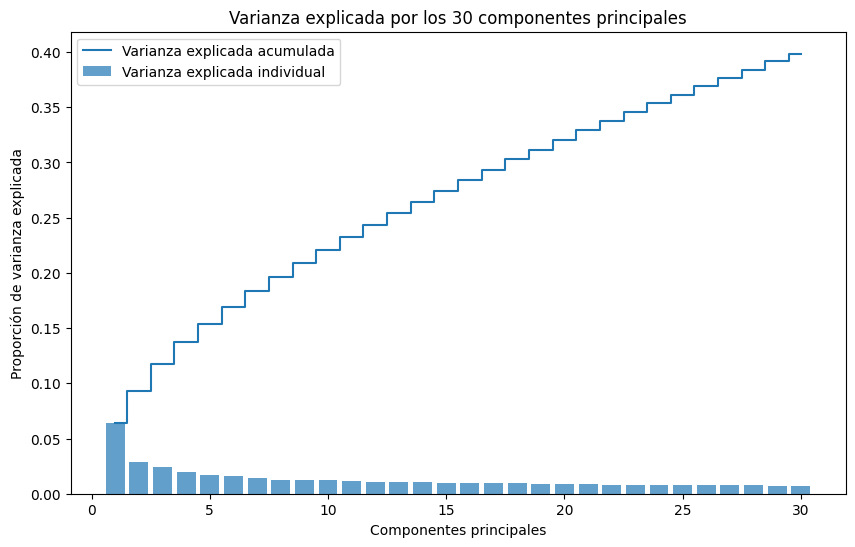

In [24]:
# Importación de las librerías necesarias
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Cargar el dataset utilizando la ruta absoluta correcta
df = pd.read_csv('/workspace/dataset.csv')

# Revisión inicial del dataset
print(df.info())

# Identificación de valores faltantes
missing_values = df.isnull().sum()
print("Valores faltantes en cada columna:\n", missing_values[missing_values > 0])

# Imputar la mediana para las columnas numéricas
df = df.fillna(df.median(numeric_only=True))

# Imputar el valor más frecuente (modo) para las columnas categóricas
for column in df.select_dtypes(include=['object']).columns:
    df[column] = df[column].fillna(df[column].mode()[0])

# Codificación de variables categóricas
df_clean = pd.get_dummies(df)

# Normalización de las características numéricas antes de aplicar PCA
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clean)

# Ajuste de PCA con el número máximo de componentes para analizar la varianza explicada acumulada
pca = PCA().fit(df_scaled)

# Ajuste de PCA con 30 componentes
pca_30 = PCA(n_components=30, random_state=42)
pca_result_30 = pca_30.fit_transform(df_scaled)
explained_variance_30 = pca_30.explained_variance_ratio_

# Calcular la varianza explicada acumulada para los 30 primeros componentes
cumulative_variance_30 = np.cumsum(explained_variance_30)
print(f"Varianza explicada acumulada por los 30 primeros componentes: {cumulative_variance_30[-1]:.2f}")

# Gráfico de la varianza explicada por cada uno de los primeros 30 componentes
plt.figure(figsize=(10,6))

# Gráfico de barras: Varianza explicada individual por cada componente
plt.bar(range(1, 31), explained_variance_30, alpha=0.7, align='center', label='Varianza explicada individual')

# Gráfico de línea: Varianza explicada acumulada
plt.step(range(1, 31), cumulative_variance_30, where='mid', label='Varianza explicada acumulada')

# Etiquetas y título
plt.xlabel('Componentes principales')
plt.ylabel('Proporción de varianza explicada')
plt.legend(loc='best')
plt.title('Varianza explicada por los 30 componentes principales')
plt.show()
